# Multi-task regression domain adaptation

In this notebook we show how to easily use the multi-task regression strategy on RDKit properties to adapt a model to a new domain.
For this example will be using the Human liver microsom dataset from Fang et al. after removing censored values as well as a BERT model pretrained using masked language modelliong (MLM) trained on 60% of the GuacaMol training set.

In [ ]:
import torch
from utils import adapt_model_with_mtr
import pandas as pd

df = pd.read_csv("adme_microsom_stab_h_cleaned.csv")


def first_token(outputs):
    token_embeddings = outputs.last_hidden_state
    summary = token_embeddings[:, 0, :]
    return summary


orig, adapted, tokens = adapt_model_with_mtr(
    model_name="UdS-LSV/da4mt-mlm-60",
    smiles=df["smiles"].tolist(),
    extract_embeddings_fn=first_token,
)

Running domain adaptation for 3 epochs on a machine with a RTX3060 GPU (12GB VRAM) takes roughly 2 minutes. On CPU (Ryzen 5 2600 with 32GB memory) it takes around an hour.

We will now compute the embeddings with the pretrained model and the domain adapated model and then evaluate their performance using a random forest regressor.

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.utils import gen_batches
from tqdm import tqdm

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
orig = orig.to(device)
adapted = adapted.to(device)

embeddings_orig = []
embeddings_adapted = []
with torch.no_grad():
    for batch in tqdm(
        gen_batches(len(df), batch_size=256), desc="Computing embeddings"
    ):
        inputs = {k: v[batch].to(device) for k, v in tokens.items()}
        orig_output = orig(**inputs)
        embeddings_orig.append(first_token(orig_output))
        embeddings_adapted.append(adapted.embeddings(**inputs))

Computing embeddings: 9it [00:21,  2.43s/it]


In [4]:
embeddings_orig = torch.vstack(embeddings_orig).cpu().numpy()
embeddings_adapted = torch.vstack(embeddings_adapted).cpu().numpy()

For the sake of the example we will use a random train test split to evaluate the performance. Please refer to the publication to see the results on cross validated scaffold splits.

In [5]:
results = []
y = df["microsom_stab_h"].values
for X, name in [(embeddings_orig, "Original"), (embeddings_adapted, "Adapted")]:
    X_train, X_test, y_train, y_test = train_test_split(X, y)

    rf = RandomForestRegressor()
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append((name, mae, "MAE"))
    results.append((name, r2, "R2"))

results_df = pd.DataFrame(results, columns=["Name", "Value", "Score"])

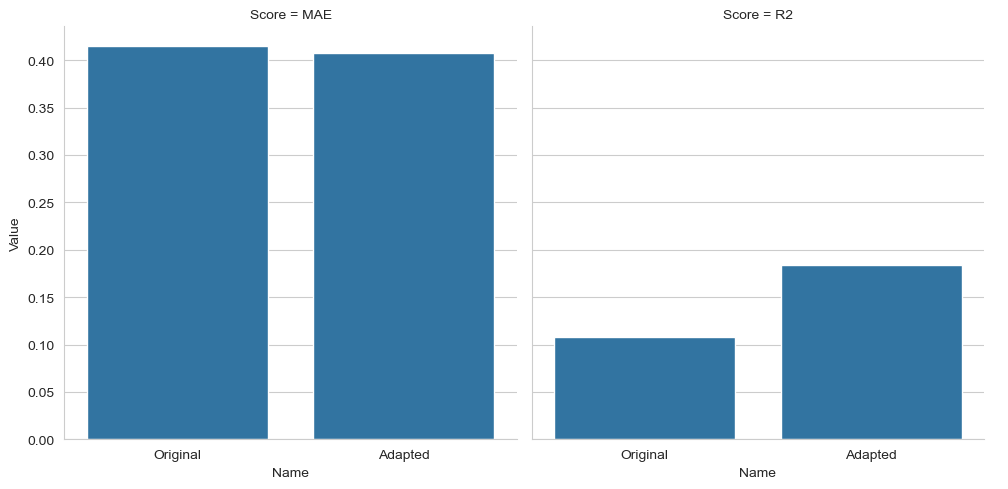

In [6]:
import seaborn as sns

g = sns.catplot(results_df, x="Name", y="Value", col="Score", kind="bar")